<a href="https://colab.research.google.com/github/Semedw/Glint_project/blob/main/notebook8b90c974c6_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb

RANDOM_STATE = 42

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
print(f" train head is:", df_train.head())
print(f" test head is:", df_test.head())
df_train.head()
df_test.head()

 train head is:     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  985          90       RL         75.0    10125   Pave   NaN      Reg   
1  778          20       RL        100.0    13350   Pave   NaN      IR1   
2  708         120       RL         48.0     6240   Pave   NaN      Reg   
3  599          20       RL         80.0    12984   Pave   NaN      Reg   
4  875          50       RM         52.0     5720   Pave   NaN      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1         Lvl    AllPub  ...        0    NaN  MnPrv         NaN       0   
2         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
3         Bnk    AllPub  ...        0    NaN    NaN         NaN       0   
4         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   

  MoSold YrSold  SaleType  SaleCondition  SalePrice  
0      8   2009       COD   

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,893,20,RL,70.0,8414,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,2,2006,WD,Normal
1,1106,60,RL,98.0,12256,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
2,414,30,RM,56.0,8960,Pave,Grvl,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,3,2010,WD,Normal
3,523,50,RM,50.0,5000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,10,2006,WD,Normal
4,1037,20,RL,89.0,12898,Pave,NaN,IR1,HLS,AllPub,...,0,0,NaN,NaN,NaN,0,9,2009,WD,Normal


In [ ]:
df_train['SalePrice'].value_counts()

,count
SalePrice,
179265,2
126910,2
132060,2
144830,2
109922,2
...,...
306315,1
133588,1
134305,1


In [ ]:
most_common = df_train["SalePrice"].mode()[0]

In [ ]:
df_test["SalePrice"] = most_common

In [ ]:
sample_submission_df = df_test[["Id", "SalePrice"]]

In [ ]:
sample_submission_df.to_csv('submission.csv', index=False)

In [ ]:
print(df_train.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQ

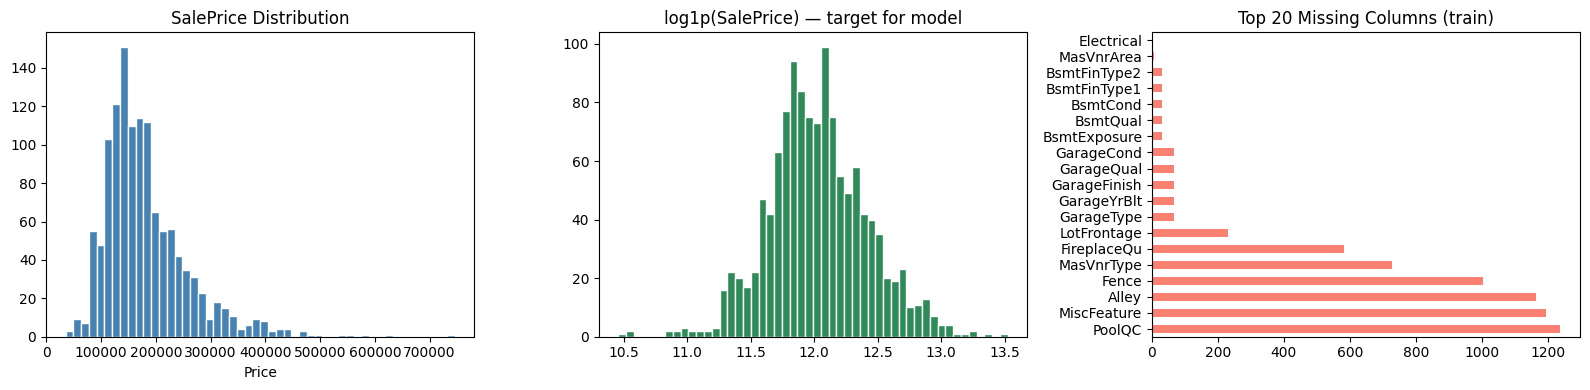

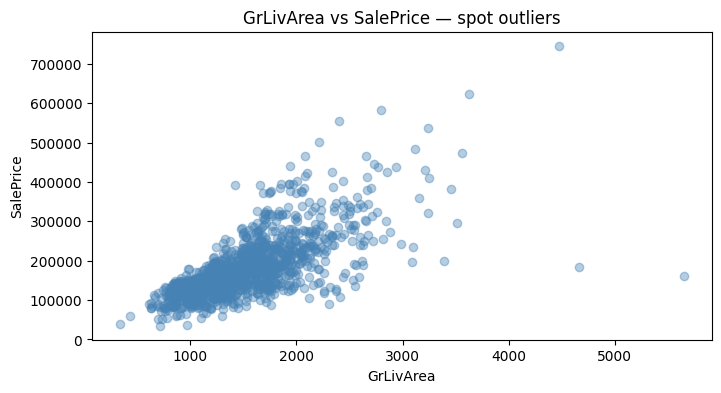

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# SalePrice distribution
axes[0].hist(df_train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('Price')

# Log-transformed SalePrice
axes[1].hist(np.log1p(df_train['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('log1p(SalePrice) — target for model')

# Missing values
missing = df_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(20)
missing.plot(kind='barh', ax=axes[2], color='salmon')
axes[2].set_title('Top 20 Missing Columns (train)')

plt.tight_layout()
plt.show()

# Outlier check: large houses with very low price
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df_train['GrLivArea'], df_train['SalePrice'], alpha=0.4, color='steelblue')
ax.set_xlabel('GrLivArea'); ax.set_ylabel('SalePrice')
ax.set_title('GrLivArea vs SalePrice — spot outliers')
plt.show()

In [ ]:
# Two well-known outliers: huge area but very low sale price
df_train = df_train[~((df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 200000))]
df_train = df_train.reset_index(drop=True)
print(f'Train after outlier removal: {df_train.shape}')

Train after outlier removal: (1239, 81)


In [ ]:
# Save target and IDs, then combine
y = np.log1p(df_train['SalePrice'])
train_ids = df_train['Id']
test_ids  = df_test['Id']
n_train   = len(df_train)

# NOTE: drop SalePrice from train before concat so test rows have no target leakage
all_data = pd.concat(
    [df_train.drop(['Id', 'SalePrice'], axis=1),
     df_test.drop(['Id'], axis=1)],
    ignore_index=True
)
print(f'Combined shape: {all_data.shape}')

Combined shape: (1458, 80)


In [ ]:
# --- Columns where NaN genuinely means 'None / does not exist' ---
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

# --- Numeric: NaN means 0 (no feature present) ---
zero_cols = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
             'GarageArea', 'GarageCars']
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

# --- LotFrontage: fill with neighborhood median (better than global median) ---
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# --- GarageYrBlt: missing means no garage → use YearBuilt as proxy ---
all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(all_data['YearBuilt'])

# --- Remaining categoricals → 'None'; remaining numerics → median ---
for col in all_data.select_dtypes(include='object').columns:
    all_data[col] = all_data[col].fillna('None')
for col in all_data.select_dtypes(include=['int64', 'float64']).columns:
    all_data[col] = all_data[col].fillna(all_data[col].median())

print('Missing after imputation:', all_data.isnull().sum().sum())

Missing after imputation: 0


In [ ]:
# MSSubClass is a category code, not an ordinal number
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)

# MoSold is a category (no natural order in housing context)
all_data['MoSold'] = all_data['MoSold'].astype(str)

# YrSold stays numeric — we'll use it for age calculations

In [ ]:
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

qual_cols = [
    'ExterQual', 'ExterCond', 'KitchenQual', 'HeatingQC',
    'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'FireplaceQu'
]
for col in qual_cols:
    all_data[col] = all_data[col].map(qual_map).fillna(0).astype(int)

# BsmtExposure has its own scale
all_data['BsmtExposure'] = all_data['BsmtExposure'].map(
    {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
).fillna(0).astype(int)

# Functional
all_data['Functional'] = all_data['Functional'].map(
    {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
).fillna(7).astype(int)

# PavedDrive
all_data['PavedDrive'] = all_data['PavedDrive'].map({'Y': 2, 'P': 1, 'N': 0}).fillna(0).astype(int)

print('Ordinal encoding done.')

Ordinal encoding done.


In [ ]:
# --- Area features ---
# TotalSF = basement + 1st floor + 2nd floor (NO garage — different value driver)
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# Porch/deck combined
all_data['TotalPorchSF'] = (
    all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
    all_data['3SsnPorch'] + all_data['ScreenPorch'] + all_data['WoodDeckSF']
)

# --- Bathroom features ---
all_data['TotalBathrooms'] = (
    all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
    all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath']
)

# --- Quality × size interactions (strongest predictors) ---
all_data['QualSF'] = all_data['OverallQual'] * all_data['GrLivArea']  # ★ best single feature
all_data['OverallGrade'] = all_data['OverallQual'] * all_data['OverallCond']
all_data['TotalQualScore'] = all_data[qual_cols].sum(axis=1)
all_data['TotalBathQuality'] = all_data['TotalBathrooms'] * all_data['KitchenQual']

# --- Age / time features ---
all_data['HouseAge']       = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge']       = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['GarageAge']      = all_data['YrSold'] - all_data['GarageYrBlt']
all_data['IsRemodeled']    = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)
all_data['IsNew']          = (all_data['HouseAge'] == 0).astype(int)

# --- Binary presence flags ---
all_data['HasGarage']    = (all_data['GarageArea']   > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces']   > 0).astype(int)
all_data['HasBasement']  = (all_data['TotalBsmtSF']  > 0).astype(int)
all_data['HasPool']      = (all_data['PoolArea']     > 0).astype(int)
all_data['Has2ndFloor']  = (all_data['2ndFlrSF']     > 0).astype(int)
all_data['HasPorch']     = (all_data['TotalPorchSF'] > 0).astype(int)

print('Feature engineering done. Shape:', all_data.shape)

Feature engineering done. Shape: (1458, 98)


In [ ]:
# IMPORTANT: compute stats only from train rows, then apply to all
# This avoids target leakage. The test rows are mapped from train stats only.
train_neigh_stats = (
    df_train.groupby('Neighborhood')['SalePrice']
    .agg(['mean', 'median'])
    .rename(columns={'mean': 'Neigh_Price_Mean', 'median': 'Neigh_Price_Median'})
)

all_data = all_data.merge(train_neigh_stats, on='Neighborhood', how='left')

# Fill any test neighborhoods not seen in train with global median
global_median = df_train['SalePrice'].median()
all_data['Neigh_Price_Mean']   = all_data['Neigh_Price_Mean'].fillna(global_median)
all_data['Neigh_Price_Median'] = all_data['Neigh_Price_Median'].fillna(global_median)

print('Neighborhood encoding done.')

Neighborhood encoding done.


In [ ]:
numeric_cols = all_data.select_dtypes(include=['int64', 'float64']).columns

# Compute skew on train portion only (to avoid leakage)
skewness = all_data[numeric_cols].iloc[:n_train].apply(skew)
skewed_features = skewness[skewness.abs() > 0.75].index

print(f'Applying log1p to {len(skewed_features)} skewed features')
all_data[skewed_features] = np.log1p(all_data[skewed_features].clip(lower=0))

Applying log1p to 36 skewed features


In [ ]:
all_data = pd.get_dummies(all_data)
print(f'After OHE: {all_data.shape}')

# Split back into train / test
X = all_data.iloc[:n_train].copy()
X_test_final = all_data.iloc[n_train:].copy()

print(f'X (train): {X.shape}   |   X_test: {X_test_final.shape}')

After OHE: (1458, 299)
X (train): (1239, 299)   |   X_test: (219, 299)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}')

X_train: (991, 299)  |  X_val: (248, 299)


In [ ]:
lgb_params = {
    'n_estimators'    : 5000,
    'learning_rate'   : 0.01,      # low LR + early stopping = better generalisation
    'num_leaves'      : 40,
    'max_depth'       : -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 1,
    'lambda_l1'       : 0.1,
    'lambda_l2'       : 0.2,
    'random_state'    : RANDOM_STATE,
    'verbose'         : -1,
}

lgb_model = lgb.LGBMRegressor(**lgb_params)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=500)
    ]
)

lgb_val_preds = lgb_model.predict(X_val)
lgb_mae = mean_absolute_error(y_val, lgb_val_preds)
print(f'\nLightGBM  Val MAE: {lgb_mae:.5f}  (best iter: {lgb_model.best_iteration_})')

[500]	valid_0's l2: 0.0156588
[1000]	valid_0's l2: 0.0148694

LightGBM  Val MAE: 0.08373  (best iter: 1215)


In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

# RidgeCV auto-selects best alpha via internal cross-validation
ridge = RidgeCV(alphas=[1, 5, 10, 20, 50, 100, 200, 500], cv=5)
ridge.fit(X_train_sc, y_train)

ridge_val_preds = ridge.predict(X_val_sc)
ridge_mae = mean_absolute_error(y_val, ridge_val_preds)
print(f'Ridge     Val RMSLE: {ridge_mae:.5f}  (best alpha: {ridge.alpha_})')

Ridge     Val RMSLE: 0.08798  (best alpha: 500)


In [ ]:
# Try a few blending weights and pick the best
best_mae = 999
best_w = 0.7

for w in np.arange(0.5, 1.0, 0.05):
    blend = w * lgb_val_preds + (1 - w) * ridge_val_preds
    mae = mean_absolute_error(y_val, blend)
    if mae < best_mae:
        best_mae = mae
        best_w = w

print(f'Best blend weight (LGB): {best_w:.2f}')
print(f'Ensemble  Val MAE:     {best_mae:.5f}')

Best blend weight (LGB): 0.60
Ensemble  Val MAE:     0.08207


In [ ]:
# After picking hyperparams with val set, run KFold on full X for honest CV score
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_lgb_model = lgb.LGBMRegressor(**{**lgb_params, 'n_estimators': lgb_model.best_iteration_})

cv_scores = cross_val_score(
    cv_lgb_model, X, y,
    cv=kf,
    scoring='neg_mean_absolute_error'
)
print(f'5-Fold CV MAE: {(-cv_scores).mean():.5f} ± {(-cv_scores).std():.5f}')

5-Fold CV MAE: 0.08168 ± 0.00245


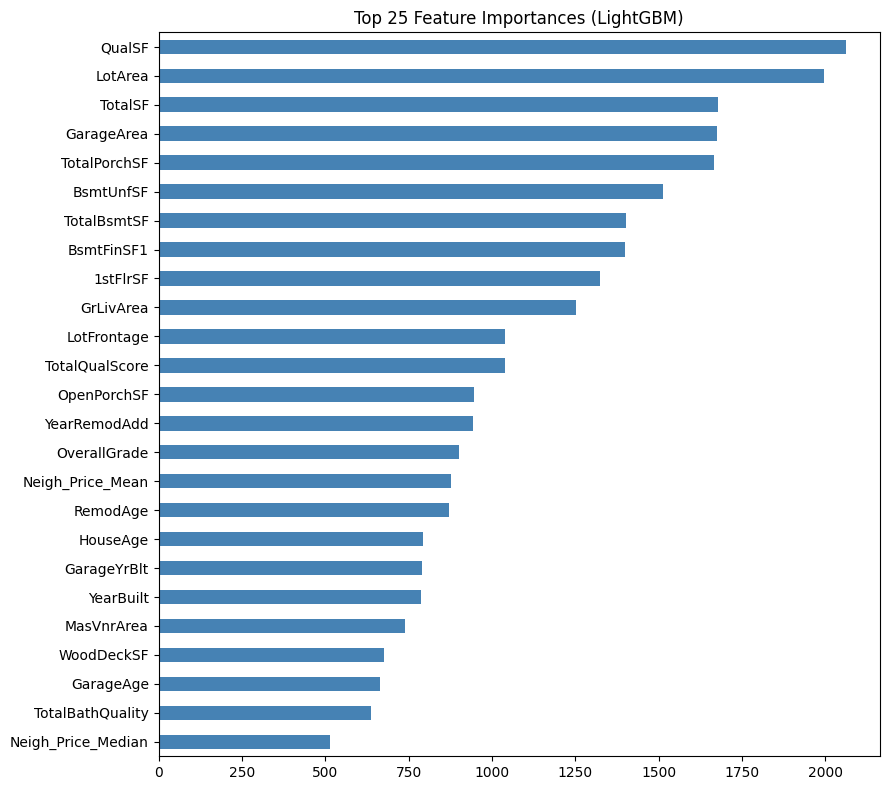

In [ ]:
importance = pd.Series(lgb_model.feature_importances_, index=X_train.columns)
importance.nlargest(25).sort_values().plot(kind='barh', figsize=(9, 8), color='steelblue')
plt.title('Top 25 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

In [ ]:
# Retrain LightGBM on ALL train data with the best iteration count found via early stopping
final_lgb = lgb.LGBMRegressor(**{**lgb_params, 'n_estimators': lgb_model.best_iteration_})
final_lgb.fit(X, y)

# Retrain Ridge on ALL train data
scaler_full = StandardScaler()
X_full_sc = scaler_full.fit_transform(X)
X_test_sc = scaler_full.transform(X_test_final)

final_ridge = RidgeCV(alphas=[1, 5, 10, 20, 50, 100, 200, 500], cv=5)
final_ridge.fit(X_full_sc, y)

# Predict in log-space
test_preds_lgb   = final_lgb.predict(X_test_final)
test_preds_ridge = final_ridge.predict(X_test_sc)

# Blend with best weight found above
test_preds_log = best_w * test_preds_lgb + (1 - best_w) * test_preds_ridge

# Convert back from log-space to dollar prices
test_preds = np.expm1(test_preds_log)

# Safety: no negative prices
test_preds = np.maximum(test_preds, 0)

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': test_preds})
submission.to_csv('submission.csv', index=False)

print(f'Submission saved. Shape: {submission.shape}')
print(submission['SalePrice'].describe().round(0))
submission

Submission saved. Shape: (219, 2)
count       219.0
mean     178729.0
std       81390.0
min       51399.0
25%      126419.0
50%      151559.0
75%      208551.0
max      583262.0
Name: SalePrice, dtype: float64


,Id,SalePrice
0,893,146507.194008
1,1106,317030.375842
2,414,104928.779251
3,523,162185.779748
4,1037,309014.945091
...,...,...
214,272,195035.770239
215,241,267078.502671
216,598,187849.087659
217,947,143983.297821
